# Text Generation with Dynamic Neural Network

This notebook demonstrates building a generative model using DynamicNetwork for next-word prediction.

## Features:
- **Bilingual**: English + Arabic text generation
- **5 Pattern Types**: Associations, Categories, Sequences, Templates, Analogies
- **100K Training Records**: 80K train / 10K val / 10K test
- **First Principles Design**: Patterns designed for BoW + softmax architecture

## 1. Setup and Imports

In [1]:
import sys
import os
import numpy as np
import time

# Add paths
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(notebook_dir, '..', '..', '..'))
src_dir = os.path.abspath(os.path.join(notebook_dir, '..'))

sys.path.insert(0, os.path.join(project_root, 'python'))
sys.path.insert(0, src_dir)

print(f"Project root: {project_root}")
print(f"Source dir: {src_dir}")

Project root: c:\Workspaces\dynamic_nn
Source dir: c:\Workspaces\dynamic_nn\notebooks\gen_model


In [2]:
# Import our modules
from src.data_generator import GenerativeDataGenerator, generate_dataset, get_data_statistics
from src.tokenizer import GenerativeTokenizer, normalize_features, one_hot_encode
from src.trainer import GenerativeTrainer
from src.evaluator import GenerativeEvaluator

# Import DynamicNetwork for visualization
from pydnn import DynamicNetwork
from pydnn.visualization import auto_generate_plots

print("All imports successful!")

All imports successful!


## 2. Generate Training Data (100K Samples)

In [3]:
# Configuration
NUM_SAMPLES = 1000000
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
SEED = 87
EN_RATIO = 0.5  # 60% English, 40% Arabic

DATA_DIR = "./"  # Save in same directory as notebook

print(f"Generating {NUM_SAMPLES:,} samples...")
print(f"  Train: {int(NUM_SAMPLES * TRAIN_RATIO):,}")
print(f"  Val:   {int(NUM_SAMPLES * VAL_RATIO):,}")
print(f"  Test:  {int(NUM_SAMPLES * (1 - TRAIN_RATIO - VAL_RATIO)):,}")

Generating 1,000,000 samples...
  Train: 800,000
  Val:   100,000
  Test:  99,999


In [4]:
# Generate dataset
start_time = time.time()

train_file, val_file, test_file = generate_dataset(
    num_samples=NUM_SAMPLES,
    output_dir=DATA_DIR,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    seed=SEED,
    en_ratio=EN_RATIO
)

elapsed = time.time() - start_time
print(f"\nData generation completed in {elapsed:.2f}s")

Generating 1,000,000 samples...
Generated 1,000,000 samples
Training samples: 800,000 -> ./train.csv
Validation samples: 100,000 -> ./val.csv
Test samples: 100,000 -> ./test.csv

Data generation completed in 6.66s


## 3. Load and Explore Data

In [5]:
# Load data
generator = GenerativeDataGenerator(seed=SEED)

train_inputs, train_outputs, train_patterns, train_langs = generator.load_from_csv(train_file)
val_inputs, val_outputs, val_patterns, val_langs = generator.load_from_csv(val_file)
test_inputs, test_outputs, test_patterns, test_langs = generator.load_from_csv(test_file)

print(f"Loaded data:")
print(f"  Train: {len(train_inputs):,} samples")
print(f"  Val:   {len(val_inputs):,} samples")
print(f"  Test:  {len(test_inputs):,} samples")

Loaded data:
  Train: 800,000 samples
  Val:   100,000 samples
  Test:  100,000 samples


In [6]:
# Data statistics
stats = get_data_statistics(train_inputs, train_outputs, train_patterns, train_langs)

print("\nTraining Data Statistics:")
print(f"  Total samples: {stats['total_samples']:,}")
print(f"  Unique inputs: {stats['unique_inputs']:,}")
print(f"  Unique outputs: {stats['unique_outputs']:,}")
print(f"  Avg input words: {stats['avg_input_words']:.2f}")

print("\nPattern Distribution:")
for pattern, count in sorted(stats['pattern_distribution'].items()):
    pct = count / stats['total_samples'] * 100
    print(f"  {pattern:15s}: {count:,} ({pct:.1f}%)")

print("\nLanguage Distribution:")
for lang, count in sorted(stats['language_distribution'].items()):
    pct = count / stats['total_samples'] * 100
    print(f"  {lang:15s}: {count:,} ({pct:.1f}%)")


Training Data Statistics:
  Total samples: 800,000
  Unique inputs: 46,688
  Unique outputs: 350
  Avg input words: 3.11

Pattern Distribution:
  analogy        : 160,233 (20.0%)
  association    : 159,683 (20.0%)
  category       : 159,741 (20.0%)
  sequence       : 160,306 (20.0%)
  template       : 160,037 (20.0%)

Language Distribution:
  ar             : 399,919 (50.0%)
  en             : 400,081 (50.0%)


In [7]:
# Show sample data for each pattern type
print("\nSample Data by Pattern Type:")
print("=" * 70)

shown_patterns = set()
for i in range(len(train_inputs)):
    pattern = train_patterns[i]
    if pattern not in shown_patterns:
        print(f"\n{pattern.upper()}:")
        # Show 2 examples per pattern (1 EN, 1 AR if available)
        count = 0
        for j in range(i, min(i + 100, len(train_inputs))):
            if train_patterns[j] == pattern:
                print(f"  [{train_langs[j]}] '{train_inputs[j]}' -> '{train_outputs[j]}'")
                count += 1
                if count >= 4:
                    break
        shown_patterns.add(pattern)
    if len(shown_patterns) >= 5:
        break


Sample Data by Pattern Type:

TEMPLATE:
  [en] 'the cold ice is' -> 'hard'
  [en] 'the short girl is' -> 'young'
  [ar] 'البيت الصغير هو' -> 'جديد'
  [ar] 'السيارة الصغير هو' -> 'بطيئة'

ASSOCIATION:
  [en] 'color pink' -> 'pig'
  [en] 'farm animal' -> 'cow'
  [ar] 'حيوان طائر' -> 'خفاش'
  [en] 'color purple' -> 'grape'

ANALOGY:
  [en] 'king man woman' -> 'queen'
  [en] 'daughter female male' -> 'son'
  [en] 'bird chick fish' -> 'fry'
  [en] 'large ocean pond' -> 'small'

CATEGORY:
  [en] 'food bread milk' -> 'rice'
  [en] 'fruit strawberry grape apple kiwi' -> 'peach'
  [ar] 'مركبة دراجة نارية دراجة قطار' -> 'شاحنة'
  [ar] 'رقم ثلاثة خمسة سبعة' -> 'اربعة'

SEQUENCE:
  [en] 'eight nine ten' -> 'eleven'
  [en] 'three five seven' -> 'nine'
  [en] 'second third fourth' -> 'fifth'
  [en] 'nine ten eleven' -> 'twelve'


## 4. Tokenization

In [8]:
# Build tokenizer
tokenizer = GenerativeTokenizer(max_vocab_size=1000)

print("Building vocabularies...")
tokenizer.fit(train_inputs, train_outputs, verbose=True)

Building vocabularies...
  Building vocabularies from 800,000 samples...
  Vocabularies built in 2.20s
  Input vocabulary size: 434
  Output vocabulary size: 350
  Unique input words: 433


In [9]:
# Tokenizer summary
vocab_summary = tokenizer.get_vocab_summary(top_n=15)

print("\nVocabulary Summary:")
print(f"  Input vocab size:  {vocab_summary['input_vocab_size']:,}")
print(f"  Output vocab size: {vocab_summary['output_vocab_size']:,}")

print("\nTop Input Words:")
for word, count in vocab_summary['top_input_words'][:10]:
    print(f"  {word:20s}: {count:,}")

print("\nSample Output Mappings:")
for word, idx in list(vocab_summary['sample_output_mappings'])[:10]:
    print(f"  {word:20s} -> {idx}")


Vocabulary Summary:
  Input vocab size:  434
  Output vocab size: 350

Top Input Words:
  the                 : 80,049
  is                  : 80,049
  هو                  : 79,988
  لون                 : 66,551
  color               : 63,271
  حيوان               : 39,836
  animal              : 36,617
  seven               : 28,564
  eight               : 28,547
  five                : 28,511

Sample Output Mappings:
  amethyst             -> 0
  annoying             -> 1
  apple                -> 2
  arm                  -> 3
  aunt                 -> 4
  autumn               -> 5
  banana               -> 6
  bat                  -> 7
  bear                 -> 8
  bee                  -> 9


In [10]:
# Transform data
print("\nTransforming training data...")
X_train = tokenizer.transform_input(train_inputs, verbose=True)
y_train_idx = tokenizer.transform_output(train_outputs, verbose=True)

print("\nTransforming validation data...")
X_val = tokenizer.transform_input(val_inputs, verbose=False)
y_val_idx = tokenizer.transform_output(val_outputs, verbose=False)

print("\nTransforming test data...")
X_test = tokenizer.transform_input(test_inputs, verbose=False)
y_test_idx = tokenizer.transform_output(test_outputs, verbose=False)


Transforming training data...
  Converting 800,000 texts to bag-of-words...
    Processed 10,000 / 800,000 texts...
    Processed 20,000 / 800,000 texts...
    Processed 30,000 / 800,000 texts...
    Processed 40,000 / 800,000 texts...
    Processed 50,000 / 800,000 texts...
    Processed 60,000 / 800,000 texts...
    Processed 70,000 / 800,000 texts...
    Processed 80,000 / 800,000 texts...
    Processed 90,000 / 800,000 texts...
    Processed 100,000 / 800,000 texts...
    Processed 110,000 / 800,000 texts...
    Processed 120,000 / 800,000 texts...
    Processed 130,000 / 800,000 texts...
    Processed 140,000 / 800,000 texts...
    Processed 150,000 / 800,000 texts...
    Processed 160,000 / 800,000 texts...
    Processed 170,000 / 800,000 texts...
    Processed 180,000 / 800,000 texts...
    Processed 190,000 / 800,000 texts...
    Processed 200,000 / 800,000 texts...
    Processed 210,000 / 800,000 texts...
    Processed 220,000 / 800,000 texts...
    Processed 230,000 / 800,00

In [11]:
# Normalize features
X_train = normalize_features(X_train)
X_val = normalize_features(X_val)
X_test = normalize_features(X_test)

# One-hot encode outputs
num_classes = tokenizer.output_vocab_size
y_train = one_hot_encode(y_train_idx, num_classes)
y_val = one_hot_encode(y_val_idx, num_classes)
y_test = one_hot_encode(y_test_idx, num_classes)

print(f"\nFinal Data Shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_test:  {y_test.shape}")


Final Data Shapes:
  X_train: (800000, 434)
  y_train: (800000, 350)
  X_val:   (100000, 434)
  y_val:   (100000, 350)
  X_test:  (100000, 434)
  y_test:  (100000, 350)


## 5. Training

In [12]:
# Create trainer
trainer = GenerativeTrainer(
    input_vocab_size=tokenizer.input_vocab_size,
    output_vocab_size=tokenizer.output_vocab_size,
    seed=SEED,
    cost_function="CrossEntropy"
)

# Set tokenizer for inference
trainer.set_tokenizer(tokenizer)

print(f"Trainer configured:")
print(f"  Input vocab:  {trainer.input_vocab_size}")
print(f"  Output vocab: {trainer.output_vocab_size}")
print(f"  Cost function: {trainer.cost_function}")

Trainer configured:
  Input vocab:  434
  Output vocab: 350
  Cost function: CrossEntropy


In [13]:
# Build network
network = trainer.build_network()

print(f"\nNetwork built:")
print(f"  Input shape: {network.input_shape}")
print(f"  Output size: {network.output_size}")

Note: Using pure Python fallback. For best performance, build C++ extensions.

Network built:
  Input shape: (434,)
  Output size: 350


In [14]:
# Train!
print("\n" + "=" * 50)
print("TRAINING")
print("=" * 50)

metrics = trainer.train(X_train, y_train, verbose=True)

print("\n" + "=" * 50)
print("TRAINING COMPLETE")
print("=" * 50)
print(f"  Epochs:          {metrics.epochs_completed}")
print(f"  Final cost:      {metrics.final_cost:.4f}")
print(f"  Best cost:       {metrics.best_cost:.4f}")
print(f"  Training time:   {metrics.training_time_ms / 1000:.2f}s")
print(f"  Samples/second:  {metrics.samples_per_second:,.0f}")


TRAINING

Training on 800,000 samples...
  Input shape: (800000, 434)
  Output shape: (800000, 350)
Training Dynamic Neural Network
  Input shape: (434,)
  Output size: 350
  Seed: 87
  Cost function: CrossEntropy
  Samples: 800000

  Epoch 0: cost=1.046539, lr=0.100000
  Epoch 10: cost=0.716329, lr=0.100000
  Epoch 20: cost=0.711682, lr=0.080000
  Epoch 30: cost=0.702622, lr=0.080000
  Epoch 40: cost=0.701947, lr=0.064000
  Epoch 50: cost=0.700370, lr=0.064000
  Epoch 60: cost=0.697722, lr=0.051200
  Epoch 70: cost=0.697007, lr=0.051200
  Epoch 80: cost=0.695774, lr=0.040960
  Epoch 90: cost=0.695461, lr=0.040960

Training complete!
  Epochs: 100
  Final cost: 0.695358
  Final efficiency: 0.4999
  Stopping reason: Training completed

TRAINING COMPLETE
  Epochs:          100
  Final cost:      0.6954
  Best cost:       0.6954
  Training time:   6930.37s
  Samples/second:  115


In [15]:
# Network health
health = trainer.get_health_status()

print("\nNetwork Health:")
print(f"  State:           {health['state']}")
print(f"  Overall health:  {health['overall_health']:.2%}")
print(f"  Cancer score:    {health['cancer_score']:.2%}")
print(f"  Alzheimer score: {health['alzheimer_score']:.2%}")
print(f"  Layers:          {health['current_layers']}")
print(f"  Nodes:           {health['current_nodes']}")
print(f"  Diagnosis:       {health['diagnosis']}")


Network Health:
  State:           Healthy
  Overall health:  100.00%
  Cancer score:    0.00%
  Alzheimer score: 0.00%
  Layers:          2
  Nodes:           739
  Diagnosis:       Network is healthy


## 6. Evaluation

In [16]:
# Create evaluator
evaluator = GenerativeEvaluator(trainer, tokenizer)

In [17]:
# Evaluate on test set
results = evaluator.evaluate(
    test_inputs,
    test_outputs,
    pattern_types=test_patterns,
    languages=test_langs,
    verbose=True
)


Evaluating on 100,000 samples...

EVALUATION RESULTS

Overall Metrics:
  Total Samples:    100,000
  Exact Accuracy:   66.68%
  Top-3 Accuracy:   80.89%
  Top-5 Accuracy:   94.80%
  Perplexity:       2.05

Per-Pattern Accuracy:
  analogy        : 100.00% (19803/19803)
  association    : 20.08% (4030/20071)
  category       : 14.78% (2997/20278)
  sequence       : 100.00% (19805/19805)
  template       : 100.00% (20043/20043)

Per-Language Accuracy:
  ar             : 66.58% (33277/49978)
  en             : 66.77% (33401/50022)


In [18]:
# Show correct predictions
print("\nCorrect Predictions:")
evaluator.show_examples(
    test_inputs[:500],
    test_outputs[:500],
    pattern_types=test_patterns[:500],
    n_examples=10,
    show_errors_only=False
)


Correct Predictions:

PREDICTION EXAMPLES

[OK] Pattern: association
  Input:      'sea animal'
  Expected:   'fish'
  Predicted:  'fish' (20.46%)
  Top-3:      fish (20.46%), whale (20.29%), shark (20.15%)

[OK] Pattern: template
  Input:      'الماء البارد هو'
  Expected:   'منعش'
  Predicted:  'منعش' (100.00%)
  Top-3:      منعش (100.00%), قاس (0.00%), صلب (0.00%)

[XX] Pattern: category
  Input:      'طعام خبز سلطة ارز شوربة'
  Expected:   'جبن'
  Predicted:  'معكرونة' (19.38%)
  Top-3:      معكرونة (19.38%), حليب (18.49%), جبن (17.58%)

[OK] Pattern: analogy
  Input:      'صغير فار فيل'
  Expected:   'كبير'
  Predicted:  'كبير' (99.99%)
  Top-3:      كبير (99.99%), صغير (0.01%), اسد (0.00%)

[OK] Pattern: association
  Input:      'farm animal'
  Expected:   'sheep'
  Predicted:  'sheep' (20.90%)
  Top-3:      sheep (20.90%), horse (20.34%), pig (20.11%)

[XX] Pattern: association
  Input:      'حيوان بري'
  Expected:   'فيل'
  Predicted:  'ذئب' (20.49%)
  Top-3:      ذئب (20.49%

In [19]:
# Show errors
print("\nIncorrect Predictions (Errors):")
evaluator.show_examples(
    test_inputs,
    test_outputs,
    pattern_types=test_patterns,
    n_examples=10,
    show_errors_only=True
)


Incorrect Predictions (Errors):

PREDICTION EXAMPLES

[XX] Pattern: category
  Input:      'طعام خبز سلطة ارز شوربة'
  Expected:   'جبن'
  Predicted:  'معكرونة' (19.38%)
  Top-3:      معكرونة (19.38%), حليب (18.49%), جبن (17.58%)

[XX] Pattern: association
  Input:      'حيوان بري'
  Expected:   'فيل'
  Predicted:  'ذئب' (20.49%)
  Top-3:      ذئب (20.49%), نمر (20.44%), اسد (19.95%)

[XX] Pattern: category
  Input:      'weather storm cloud'
  Expected:   'lightning'
  Predicted:  'hail' (20.17%)
  Top-3:      hail (20.17%), wind (16.98%), snow (12.75%)

[XX] Pattern: category
  Input:      'color yellow pink white'
  Expected:   'black'
  Predicted:  'brown' (20.81%)
  Top-3:      brown (20.81%), purple (19.89%), green (17.67%)

[XX] Pattern: association
  Input:      'flying animal'
  Expected:   'butterfly'
  Predicted:  'bat' (21.59%)
  Top-3:      bat (21.59%), butterfly (20.35%), eagle (19.72%)

[XX] Pattern: category
  Input:      'body nose hand mouth'
  Expected:   'finger'


## 7. Generation Demo

In [20]:
# Interactive generation demo
evaluator.generation_demo(temperature=1.0)


GENERATION DEMO

  Context:    'color red'
  Generated:  'strawberry' (21.68%)
  Top-3:      strawberry (22%), fire (22%), tomato (20%)

  Context:    'color blue'
  Generated:  'sky' (20.97%)
  Top-3:      sky (21%), water (21%), ocean (20%)

  Context:    'one two three'
  Generated:  'four' (99.98%)
  Top-3:      four (100%), five (0%), eight (0%)

  Context:    'first second third'
  Generated:  'fourth' (99.99%)
  Top-3:      fourth (100%), fifth (0%), ستة (0%)

  Context:    'fruit apple banana'
  Generated:  'mango' (18.11%)
  Top-3:      mango (18%), peach (15%), pear (13%)

  Context:    'animal cat dog'
  Generated:  'fish' (17.75%)
  Top-3:      fish (18%), tiger (14%), cow (14%)

  Context:    'the big house is'
  Generated:  'old' (99.98%)
  Top-3:      old (100%), new (0%), tall (0%)

  Context:    'king man woman'
  Generated:  'queen' (99.98%)
  Top-3:      queen (100%), husband (0%), mother (0%)

  Context:    'لون احمر'
  Generated:  'كرز' (21.45%)
  Top-3:      كرز 

In [21]:
# Custom generation examples
custom_contexts = [
    # Test associations
    "color green",
    "color black",
    "pet animal",
    
    # Test sequences
    "four five six",
    "second third fourth",
    
    # Test categories
    "fruit grape mango",
    "animal lion tiger",
    
    # Test analogies
    "hot fire ice",
    "big elephant mouse",
    
    # Arabic tests
    "لون اخضر",
    "اربعة خمسة ستة",
    "حيوان اسد نمر",
]

print("\nCustom Generation Tests:")
print("=" * 60)

for context in custom_contexts:
    word, confidence = trainer.generate_next_word(context)
    print(f"  '{context}' -> '{word}' ({confidence:.2%})")


Custom Generation Tests:
  'color green' -> 'grass' (20.96%)
  'color black' -> 'coal' (20.65%)
  'pet animal' -> 'fish' (21.33%)
  'four five six' -> 'seven' (99.98%)
  'second third fourth' -> 'fifth' (99.99%)
  'fruit grape mango' -> 'orange' (16.16%)
  'animal lion tiger' -> 'fish' (22.62%)
  'hot fire ice' -> 'cold' (99.98%)
  'big elephant mouse' -> 'small' (99.99%)
  'لون اخضر' -> 'خيار' (21.44%)
  'اربعة خمسة ستة' -> 'سبعة' (99.99%)
  'حيوان اسد نمر' -> 'سمكة' (19.03%)


In [22]:
# Multi-word generation
print("\nMulti-Word Generation:")
print("=" * 60)

seed_texts = [
    "one two",
    "color",
    "fruit apple",
]

for seed in seed_texts:
    sequence = trainer.generate_sequence(seed, num_words=3, temperature=0.8)
    generated_words = [w for w, c in sequence]
    print(f"\n  Seed: '{seed}'")
    print(f"  Generated: {' -> '.join(generated_words)}")
    for word, conf in sequence:
        print(f"    {word}: {conf:.2%}")


Multi-Word Generation:

  Seed: 'one two'
  Generated: four -> eight -> ten
    four: 99.85%
    eight: 88.51%
    ten: 95.81%

  Seed: 'color'
  Generated: sun
    sun: 9.01%

  Seed: 'fruit apple'
  Generated: banana -> mango -> orange
    banana: 14.31%
    mango: 19.74%
    orange: 23.53%


## 8. Save Model

In [23]:
# Save trained model
MODEL_DIR = "./models"
os.makedirs(MODEL_DIR, exist_ok=True)

trainer.save(MODEL_DIR, "generative_model")
print(f"Model saved to {MODEL_DIR}/generative_model.json")

Model saved to ./models/generative_model.json


In [24]:
# Verify model can be loaded
loaded_trainer = GenerativeTrainer.load(os.path.join(MODEL_DIR, "generative_model.json"))
loaded_trainer.set_tokenizer(tokenizer)

# Test loaded model
test_word, test_conf = loaded_trainer.generate_next_word("color red")
print(f"Loaded model test: 'color red' -> '{test_word}' ({test_conf:.2%})")

Note: Using pure Python fallback. For best performance, build C++ extensions.
Loaded model test: 'color red' -> 'strawberry' (21.68%)


## 9. Visualization

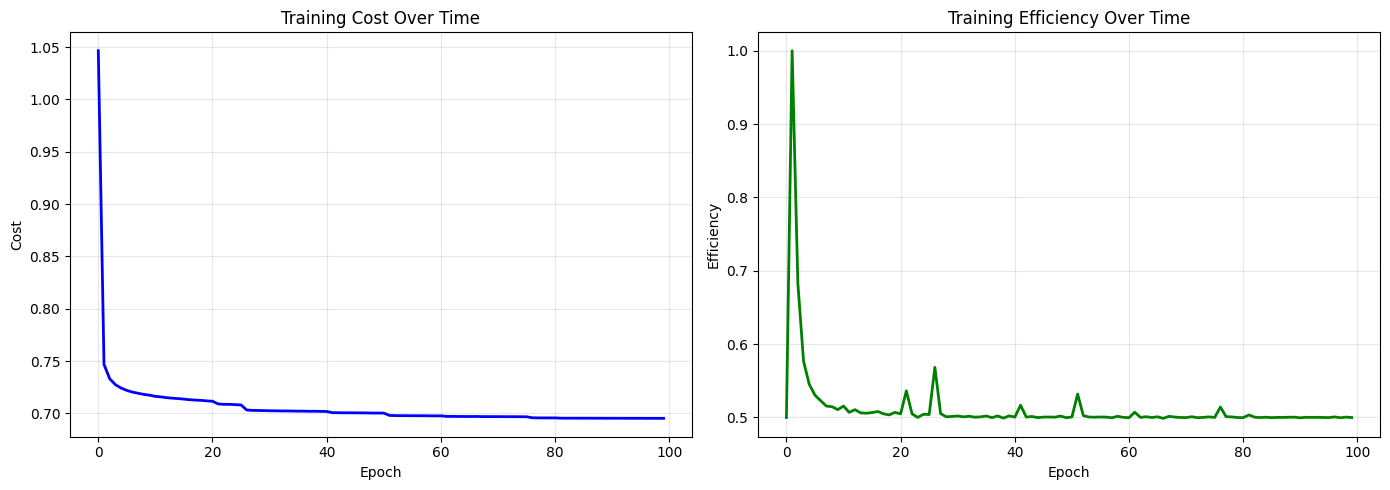

Saved training_history.png


In [25]:
# Plot training history
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cost history
axes[0].plot(metrics.cost_history, 'b-', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cost')
axes[0].set_title('Training Cost Over Time')
axes[0].grid(True, alpha=0.3)

# Efficiency history
axes[1].plot(metrics.efficiency_history, 'g-', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Efficiency')
axes[1].set_title('Training Efficiency Over Time')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved training_history.png")

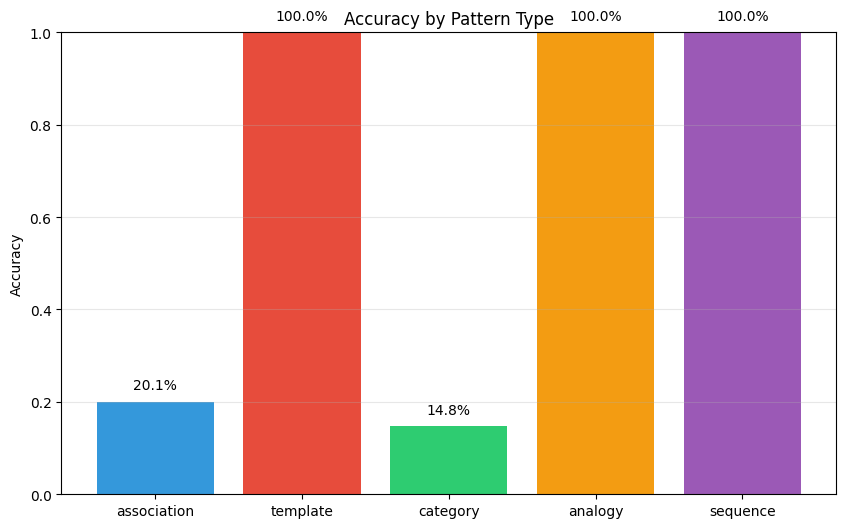

Saved pattern_accuracy.png


In [26]:
# Per-pattern accuracy visualization
if 'per_pattern' in results:
    patterns = list(results['per_pattern'].keys())
    accuracies = [results['per_pattern'][p]['accuracy'] for p in patterns]
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(patterns, accuracies, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6'])
    plt.ylabel('Accuracy')
    plt.title('Accuracy by Pattern Type')
    plt.ylim(0, 1)
    
    # Add value labels
    for bar, acc in zip(bars, accuracies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{acc:.1%}', ha='center', va='bottom', fontsize=10)
    
    plt.grid(True, alpha=0.3, axis='y')
    plt.savefig('./pattern_accuracy.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("Saved pattern_accuracy.png")

## 10. Summary

In [27]:
print("\n" + "=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)

print(f"\nDataset:")
print(f"  Total samples:     {NUM_SAMPLES:,}")
print(f"  Training samples:  {len(train_inputs):,}")
print(f"  Validation samples: {len(val_inputs):,}")
print(f"  Test samples:      {len(test_inputs):,}")

print(f"\nModel:")
print(f"  Input vocab size:  {tokenizer.input_vocab_size:,}")
print(f"  Output vocab size: {tokenizer.output_vocab_size:,}")
print(f"  Network layers:    {health['current_layers']}")
print(f"  Network nodes:     {health['current_nodes']}")

print(f"\nTraining:")
print(f"  Epochs:            {metrics.epochs_completed}")
print(f"  Training time:     {metrics.training_time_ms / 1000:.2f}s")
print(f"  Final cost:        {metrics.final_cost:.4f}")

print(f"\nTest Performance:")
print(f"  Exact accuracy:    {results['exact_accuracy']:.2%}")
print(f"  Top-3 accuracy:    {results['top3_accuracy']:.2%}")
print(f"  Top-5 accuracy:    {results['top5_accuracy']:.2%}")
print(f"  Perplexity:        {results['perplexity']:.2f}")

print("\n" + "=" * 60)


TRAINING SUMMARY

Dataset:
  Total samples:     1,000,000
  Training samples:  800,000
  Validation samples: 100,000
  Test samples:      100,000

Model:
  Input vocab size:  434
  Output vocab size: 350
  Network layers:    2
  Network nodes:     739

Training:
  Epochs:            100
  Training time:     6930.37s
  Final cost:        0.6954

Test Performance:
  Exact accuracy:    66.68%
  Top-3 accuracy:    80.89%
  Top-5 accuracy:    94.80%
  Perplexity:        2.05

